In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

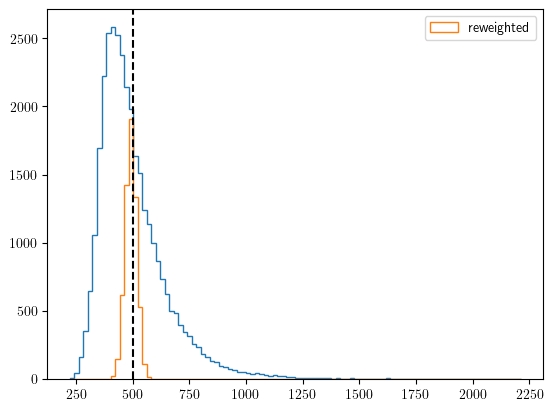

In [3]:
total_weight_df = np.sum(df_signal["weight"])

bin_edges = np.linspace(250, 1250, 101)
# target distribution: mean=500, std=25
src_hist_m4j, _ = np.histogram(df_signal["m4j"], bins=bin_edges, weights=df_signal["weight"])
bin_idx = np.digitize(df_signal["m4j"], bin_edges, right=True)
bin_idx = np.clip(bin_idx, 0, len(bin_edges) - 2)
mid_points = (bin_edges[:-1] + bin_edges[1:]) / 2
mu, sigma = 500, 25
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

tgt_pdf_m4j = gaussian(mid_points, mu, sigma)
tgt_hist_m4j = tgt_pdf_m4j * total_weight_df / np.sum(tgt_pdf_m4j)

reweight_factor = tgt_hist_m4j / src_hist_m4j
new_weight = df_signal["weight"] * reweight_factor[bin_idx]
new_weight = new_weight / np.max(new_weight) * np.max(df_signal["weight"])

plt.hist(df_signal["m4j"], bins=100, weights=df_signal["weight"], histtype="step")
plt.hist(df_signal["m4j"], bins=100, weights=new_weight, label="reweighted", histtype="step")
plt.axvline(mu, color="k", linestyle="--")
plt.legend()
plt.show()

In [35]:
np.sum(new_weight) / np.sum(df_signal["weight"])

0.18504058198857729

In [54]:
np.sum(new_weight) / df_bg4b[:100_0000].weight.sum()


0.005877512966242888

In [48]:
from copy import deepcopy

df_signal_resonant = deepcopy(df_signal)
df_signal_resonant["weight"] = new_weight
df_signal_resonant = df_signal_resonant[df_signal_resonant["weight"] > 1e-4]
# path_signal_resonant_v1 = Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5")
# df_signal_resonant.to_hdf(path_signal_resonant_v1, key="df_signal", mode="w")

# Version 2: Reweight and bootstrap

In [21]:
np.max(bin_idx)
np.min(bin_idx)

0

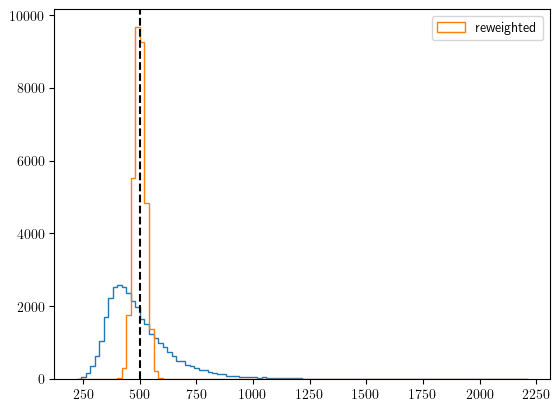

In [64]:
total_weight_df = np.sum(df_signal["weight"])

# bin_edges = np.linspace(250, 1250, 201)
# bin_edges = np.quantile(df_signal["m4j"], np.linspace(0, 1, 201))
bin_edges = np.linspace(300, 700, 201)
# target distribution: mean=500, std=25
src_hist_m4j, _ = np.histogram(df_signal["m4j"], bins=bin_edges, weights=df_signal["weight"])
src_hist_m4j_sum, _ = np.histogram(df_signal["m4j"], bins=bin_edges, weights=df_signal["weight"] * df_signal["m4j"])
bin_idx = np.digitize(df_signal["m4j"], bin_edges, right=True)
bin_centers = src_hist_m4j_sum / src_hist_m4j

mu, sigma = 500, 25
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

tgt_pdf_m4j = gaussian(bin_centers, mu, sigma)
tgt_hist_m4j = tgt_pdf_m4j * total_weight_df / np.sum(tgt_pdf_m4j)

reweight_factor = tgt_hist_m4j / src_hist_m4j
reweight_factor = np.concatenate([[0], reweight_factor, [0]])
new_weight = df_signal["weight"] * reweight_factor[bin_idx]

plt.hist(df_signal["m4j"], bins=100, weights=df_signal["weight"], histtype="step")
plt.hist(df_signal["m4j"], bins=100, weights=new_weight, label="reweighted", histtype="step")
plt.axvline(mu, color="k", linestyle="--")
plt.legend()
plt.show()

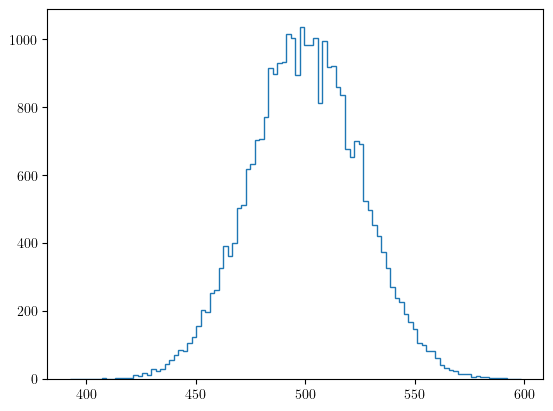

499.9379
25.109445571899414


In [65]:
from copy import deepcopy
# bootstrap using new_weight

n_samples = len(df_signal)
np.random.seed(0)
p = new_weight / np.sum(new_weight)
p = np.clip(p, 1e-9, 1)
p = p / np.sum(p)
bootstrap_indices = np.random.choice(
    np.arange(n_samples), size=n_samples, replace=True, p=p)
bootstrap_df_signal = deepcopy(df_signal.iloc[bootstrap_indices].reset_index(drop=True))
bootstrap_df_signal["weight"] = 1.0

plt.hist(bootstrap_df_signal["m4j"], bins=100, weights=bootstrap_df_signal["weight"], histtype="step")
plt.show()

print(np.mean(bootstrap_df_signal["m4j"]))
print(np.std(bootstrap_df_signal["m4j"]))

# See if it has power

In [2]:
from utils import safe_dict
from events_data import get_is_signal

experiment_name = "base_fvt_training_ensemble_HH4b_resonant"
signal_ratios = [0.005]
dataset_seeds = range(50)

hparams_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: (
        safe_dict(x, "signal_ratio") in signal_ratios
        and safe_dict(x, "seed") in dataset_seeds
    ),
}
hashes = TrainingInfo.find(hparams_filter)

df_hh4b_resonant = pd.read_hdf(Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5"))
path_signal_resonant = Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5")
loaded_df[path_signal_resonant] = df_hh4b_resonant


for hash in hashes:
    fvt_info = TrainingInfo.load(hash)
    signal_filename = fvt_info.hparams["dataset"]["signal_filename"]
    ms_hash = fvt_info.ms_hash
    ms_idx = fvt_info.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    base_fvt_model = fvt_info.load_trained_model("best")
    base_fvt_model: FvTClassifier
    base_fvt_model.eval()
    base_fvt_score = base_fvt_model.predict(events_tst.X_torch)[:, 1].numpy()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.linspace(0, 1, 100)
    hist_events_by_labels(events_tst, base_fvt_score, bins=bins, ax=ax)
    plt.show()
    

ModuleNotFoundError: No module named 'utils'

In [4]:
from utils import safe_dict
from events_data import get_is_signal

experiment_name = "base_fvt_training_ensemble_HH4b_resonant"
signal_ratios = [0.005]
dataset_seeds = range(50)

hparams_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: (
        safe_dict(x, "signal_ratio") in signal_ratios
        and safe_dict(x, "seed") in dataset_seeds
    ),
}
hashes = TrainingInfo.find(hparams_filter)

df_hh4b_resonant = pd.read_hdf(Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5"))
path_signal_resonant = Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5")
loaded_df[path_signal_resonant] = df_hh4b_resonant


for hash in hashes:
    fvt_info = TrainingInfo.load(hash)
    signal_filename = fvt_info.hparams["dataset"]["signal_filename"]
    ms_hash = fvt_info.ms_hash
    ms_idx = fvt_info.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    base_fvt_model = fvt_info.load_trained_model("best")
    base_fvt_model: FvTClassifier
    base_fvt_model.eval()
    base_fvt_score = base_fvt_model.predict(events_tst.X_torch)[:, 1].numpy()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.linspace(0, 1, 100)
    hist_events_by_labels(events_tst, base_fvt_score, bins=bins, ax=ax)
    plt.show()
    

CUDA is not available, changing device to CPU


KeyboardInterrupt: 

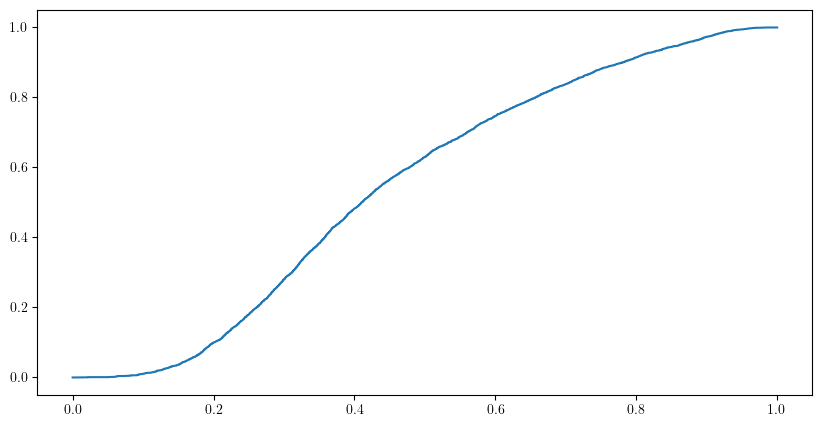

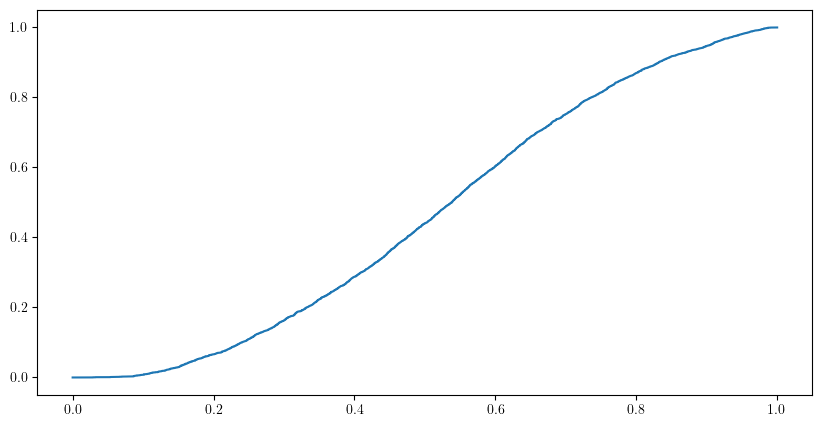

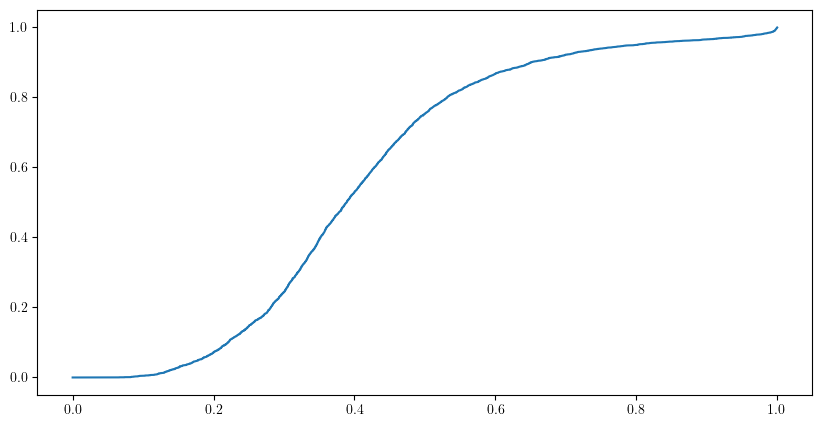

KeyboardInterrupt: 

In [7]:
from plots import plot_sr_stats
from utils import safe_dict
from events_data import get_is_signal
from fvt_classifier import AttentionClassifier, FvTClassifier

experiment_name = "smeared_fvt_training_ensemble_HH4b_resonant"
signal_ratios = [0.005]
dataset_seeds = range(50)

hparams_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: (
        safe_dict(x, "signal_ratio") in signal_ratios
        and safe_dict(x, "seed") in dataset_seeds
    ),
}
hashes = TrainingInfo.find(hparams_filter)

# df_hh4b_resonant = pd.read_hdf(Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5"))
# path_signal_resonant = Path("../events/MG3/dataframes/HH4b_resonant_picoAOD_v1.h5")
# loaded_df[path_signal_resonant] = df_hh4b_resonant


for hash in hashes:
    fvt_info = TrainingInfo.load(hash)
    base_fvt_info = TrainingInfo.load(fvt_info.hparams["encoder_hash"])
    signal_filename = fvt_info.hparams["dataset"]["signal_filename"]
    ms_hash = fvt_info.ms_hash
    ms_idx = fvt_info.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
    events_tst = EventsData.from_dataframe(df_tst, features)
    
    # print(fvt_info.aux_info.keys())
    
    # base_fvt_model = base_fvt_info.load_trained_model("best")
    # base_fvt_model: FvTClassifier
    # base_fvt_model.eval()
    # base_fvt_score, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    # base_q_repr = base_q_repr.numpy()
    # base_fvt_score = base_fvt_score[:, 1].numpy()
    
    # smeared_fvt_model = fvt_info.load_trained_model("best")
    # smeared_fvt_model: AttentionClassifier
    # smeared_fvt_model.eval()
    # smeared_fvt_score = smeared_fvt_model.predict(base_q_repr)[:, 1].numpy()
    
    base_fvt_score = base_fvt_info.aux_info["base_fvt_score"]
    smeared_fvt_score = fvt_info.aux_info["smeared_fvt_score"]
    
    gamma = base_fvt_score / (1 - base_fvt_score)
    gamma_smeared = smeared_fvt_score / (1 - smeared_fvt_score)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    # bins = np.linspace(0, 1, 100)
    # hist_events_by_labels(events_tst, np.log(gamma / gamma_smeared), bins=30, ax=ax)
    plot_sr_stats(events_tst, np.log(gamma / gamma_smeared), ax, label="ord")
    plt.show()
    